Author: David Otto, 7222573
This notebook handles the case in which instances of enrolled were relabeled by means of the knn algorithm.

In [1]:
# Get all imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Processing

In [ ]:
# Get all data
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
data = pd.read_csv("data/data_prepped_knn.csv")
X = data.drop("Target", axis=1)
y = data["Target"]

label_map = {"Dropout": 1, "Graduate": 0}
y_encoded = pd.Series([label_map[label] for label in y])

# Split train test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42)

print(f"Train-set length: {X_train.shape[0]}\nTest-set length {X_test.shape[0]}")
# Define feature types
categorical = [
    "Marital status",
    "Application mode",
    "Course",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
]

numeric = [col for col in X_train.columns if col not in categorical]

# Construc preprocessor to transform data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
    ])

Train-set length: 3539
Test-set length 885


In [ ]:
# Get all models
import joblib
from helpers.SimpleAverageEnsemble import StudentDropoutEnsemble

logreg_m = joblib.load("models/best_logreg_pipeline_knn.joblib")
rf_m = joblib.load('models/best_rf_pipeline_knn.joblib')
xgb_m = joblib.load("models/best_xgb_pipeline_knn.joblib")

ensemble = StudentDropoutEnsemble(logreg_m, rf_m, xgb_m)
avg_comb_probs_tr = ensemble.average_combinations(X_train, 2)

In [9]:
# Get all colors
colors = {'Graduate': '#A8E6CF', 'Enrolled': '#FCFC99', 'Dropout': '#FF8B94'}

## Models

In [10]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
import joblib
from scipy.stats import uniform, randint

### Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# Define search space
logreg_param_distributions = [
    # L1 and L2: no l1_ratio
    {
        'classifier__penalty': ['l1', 'l2'],
        'classifier__C': uniform(0.01, 1.0),
        'classifier__class_weight': [None, 'balanced']
    },
    # ElasticNet: includes l1_ratio
    {
        'classifier__penalty': ['elasticnet'],
        'classifier__C': uniform(0.01, 1.0),
        'classifier__l1_ratio': uniform(0.1, 0.9),
        'classifier__class_weight': [None, 'balanced']
    }
]

# Pipeline
logreg_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        solver='saga',
        max_iter=5000,
        random_state=42
    ))
])

# Randomized search
logreg_random_search = RandomizedSearchCV(
    estimator=logreg_pipe,
    param_distributions=logreg_param_distributions,
    n_iter=1000,
    cv=3,
    scoring='neg_log_loss',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit
logreg_random_search.fit(X_train, y_train)

print("Best parameters (LogReg):", logreg_random_search.best_params_)
print(f"Best log loss: {-logreg_random_search.best_score_:.3f}")

Fitting 3 folds for each of 1000 candidates, totalling 3000 fits
Best parameters (LogReg): {'classifier__C': np.float64(0.1996948481746772), 'classifier__class_weight': None, 'classifier__l1_ratio': np.float64(0.29368168481551377), 'classifier__penalty': 'elasticnet'}
Best log loss: 0.273


In [ ]:
# Extract best parameters
best_logreg_params = logreg_random_search.best_params_

# Build fine-tuned grid
if best_logreg_params['classifier__penalty'] in ['l1', 'l2']:
    logreg_param_grid_refined = {
        'classifier__penalty': [best_logreg_params['classifier__penalty']],
        'classifier__C': [round(best_logreg_params['classifier__C'] * (1 + i * 0.2), 3) for i in [-1, 0, 1]],
        'classifier__class_weight': [best_logreg_params['classifier__class_weight']]
    }
else:  # elasticnet
    logreg_param_grid_refined = {
        'classifier__penalty': ['elasticnet'],
        'classifier__C': [round(best_logreg_params['classifier__C'] * (1 + i * 0.2), 3) for i in [-1, 0, 1]],
        'classifier__class_weight': [best_logreg_params['classifier__class_weight']],
        'classifier__l1_ratio': [round(best_logreg_params['classifier__l1_ratio'] + i * 0.05, 2) for i in [-1, 0, 1]]
    }

# Run fine-tuned grid search
logreg_grid_search = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=[logreg_param_grid_refined],
    cv=3,
    scoring='neg_log_loss',
    n_jobs=-1,
    verbose=1
)

logreg_grid_search.fit(X_train, y_train)

print("Best parameters (LogReg):", logreg_grid_search.best_params_)
print(f"Best log loss: {-logreg_grid_search.best_score_:.3f}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best parameters (LogReg): {'classifier__C': np.float64(0.24), 'classifier__class_weight': None, 'classifier__l1_ratio': np.float64(0.24), 'classifier__penalty': 'elasticnet'}
Best log loss: 0.273


In [14]:
# Save the best estimator
joblib.dump(logreg_grid_search.best_estimator_, 'models/best_logreg_pipeline_knn.joblib')

['models/best_logreg_pipeline_knn.joblib']

## Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Define parameter distributions
rf_param_distributions = {
    "classifier__n_estimators": randint(500, 1200),
    "classifier__max_depth": randint(5, 30),
    "classifier__min_samples_leaf": randint(1, 10),
    "classifier__max_features": uniform(0.1, 0.9),
    "classifier__bootstrap": [True, False]
}

# Pipeline
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

# Randomized search
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_param_distributions,
    n_iter=100,
    cv=3,
    scoring='neg_log_loss',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit
rf_random_search.fit(X_train, y_train)

print("Best parameters (RF):", rf_random_search.best_params_)
print(f"Best log loss: {-rf_random_search.best_score_:.3f}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best parameters (RF): {'classifier__bootstrap': False, 'classifier__max_depth': 17, 'classifier__max_features': np.float64(0.2268318024772864), 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 1020}
Best log loss: 0.289


In [17]:
# Extract best parameters
best_rf_params = rf_random_search.best_params_

# Helper: Around function for int/float params
def around(val, step, n=1, limits=None):
    vals = [val + i * step for i in range(-n, n + 1)]
    if limits:
        vals = [max(min(v, limits[1]), limits[0]) for v in vals]
    return sorted(set(vals))

# Build fine-tuned grid
rf_param_grid_refined = {
    "classifier__n_estimators": around(best_rf_params["classifier__n_estimators"], 100, 1, (100, 2000)),
    "classifier__max_depth": around(best_rf_params["classifier__max_depth"], 2, 1, (2, 30)),
    "classifier__min_samples_leaf": around(best_rf_params["classifier__min_samples_leaf"], 1, 1, (1, 20)),
    "classifier__max_features": around(best_rf_params["classifier__max_features"], 0.05, 1, (0.1, 1.0)),
    "classifier__bootstrap": [best_rf_params["classifier__bootstrap"]]
}

# Run refined grid search
rf_grid_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid_refined,
    cv=3,
    scoring='neg_log_loss',
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

print("Best parameters (RF):", rf_grid_search.best_params_)
print(f"Best log loss: {-rf_grid_search.best_score_:.3f}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best parameters (RF): {'classifier__bootstrap': False, 'classifier__max_depth': 19, 'classifier__max_features': np.float64(0.17683180247728641), 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 920}
Best log loss: 0.289


In [18]:
# Save the best estimator
joblib.dump(rf_grid_search.best_estimator_, 'models/best_rf_pipeline_knn.joblib')

['models/best_rf_pipeline_knn.joblib']

### XGBoost

In [19]:
import xgboost as xgb

In [ ]:
# Create pipeline
xgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ("classifier", xgb.XGBClassifier(
        eval_metric="logloss",
        random_state=42,
    ))
])

# Reasonable hyperparameter distributions for randomized search
xgb_param_distributions = {
    "classifier__learning_rate": uniform(0.01, 0.2),
    "classifier__n_estimators": randint(100, 1000),
    "classifier__max_depth": randint(3, 10),
    "classifier__reg_lambda": uniform(0, 1),
    "classifier__colsample_bytree": uniform(0.3, 0.7)
}

# Randomized search with cross-validation
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=xgb_param_distributions,
    n_iter=100,
    cv=3,
    scoring='neg_log_loss',
    n_jobs=-1,
    verbose=1,
)

# Fit model with 3-fold CV
xgb_random_search.fit(X_train, y_train)

print(f"Best parameters: {xgb_random_search.best_params_}")
print(f"Best cross-validation log loss: {-xgb_random_search.best_score_:.3f}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best parameters: {'classifier__colsample_bytree': np.float64(0.3250255844214454), 'classifier__learning_rate': np.float64(0.05167102159544907), 'classifier__max_depth': 4, 'classifier__n_estimators': 278, 'classifier__reg_lambda': np.float64(0.04066024324993334)}
Best cross-validation log loss: 0.274


In [21]:
# Extract best parameters from randomized search
best_params = xgb_random_search.best_params_

# Helper function to create a small grid around a numeric value
def around(val, step=0.01, n=1, limits=(0, 1)):
    return sorted(set([
        max(min(val + i * step, limits[1]), limits[0])
        for i in range(-n, n + 1)
    ]))

# Build fine-tuned grid around best parameters
xgb_param_grid_refined = {
    "classifier__learning_rate": around(best_params["classifier__learning_rate"], step=0.01, n=1, limits=(0.001, 0.3)),
    "classifier__n_estimators": around(best_params["classifier__n_estimators"], step=50, n=1, limits=(50, 1500)),
    "classifier__max_depth": around(best_params["classifier__max_depth"], step=1, n=1, limits=(2, 15)),
    "classifier__reg_lambda": around(best_params["classifier__reg_lambda"], step=0.1, n=1, limits=(0.0, 5.0)),
    "classifier__colsample_bytree": around(best_params["classifier__colsample_bytree"], step=0.05, n=1, limits=(0.1, 1.0)),
}

# Grid search with cross-validation
xgb_grid_search = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=xgb_param_grid_refined,
    cv=3,
    scoring='neg_log_loss',
    n_jobs=-1,
    verbose=1
)

# Fit model with 3-fold CV
xgb_grid_search.fit(X_train, y_train)

print(f"Best parameters from fine-tuned grid: {xgb_grid_search.best_params_}")
print(f"Best cross-validation log loss: {-xgb_grid_search.best_score_:.3f}")

Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best parameters from fine-tuned grid: {'classifier__colsample_bytree': np.float64(0.3250255844214454), 'classifier__learning_rate': np.float64(0.06167102159544907), 'classifier__max_depth': 3, 'classifier__n_estimators': 328, 'classifier__reg_lambda': np.float64(0.14066024324993334)}
Best cross-validation log loss: 0.272


In [22]:
# Save the best estimator
joblib.dump(xgb_grid_search.best_estimator_, 'models/best_xgb_pipeline_knn.joblib')

['models/best_xgb_pipeline_knn.joblib']

## Determining Thresholds

In [40]:
from helpers.helpers import plot_precision_recall_vs_threshold_multi

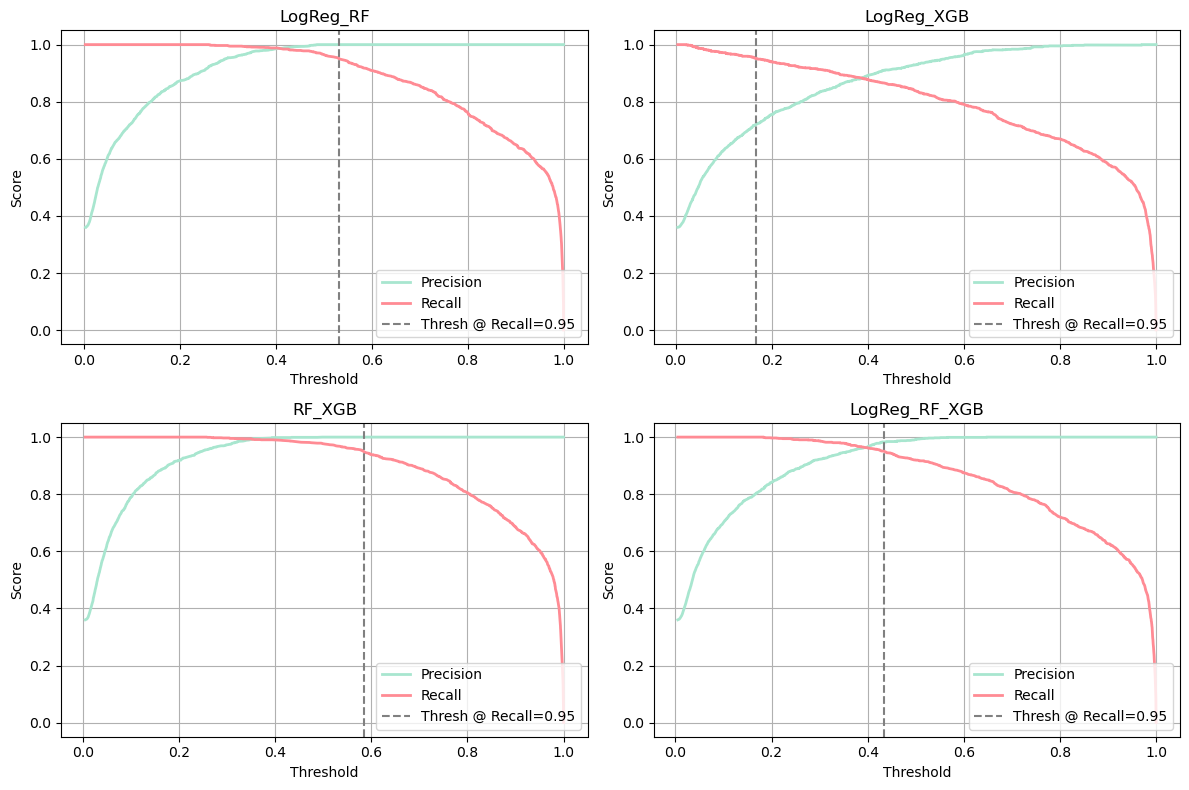

In [41]:
# Draw precision vs recall for ensemble models 
ensemble_model_results = {
    "LogReg_RF":(y_train, avg_comb_probs_tr["LogReg_RF"]),
    "LogReg_XGB": (y_train, avg_comb_probs_tr["LogReg_XGB"]),
    "RF_XGB": (y_train, avg_comb_probs_tr["RF_XGB"]),
    "LogReg_RF_XGB": (y_train, avg_comb_probs_tr["LogReg_RF_XGB"])
}

thresholds_ensemble = plot_precision_recall_vs_threshold_multi(ensemble_model_results, target_recall=0.95, ncols=2)

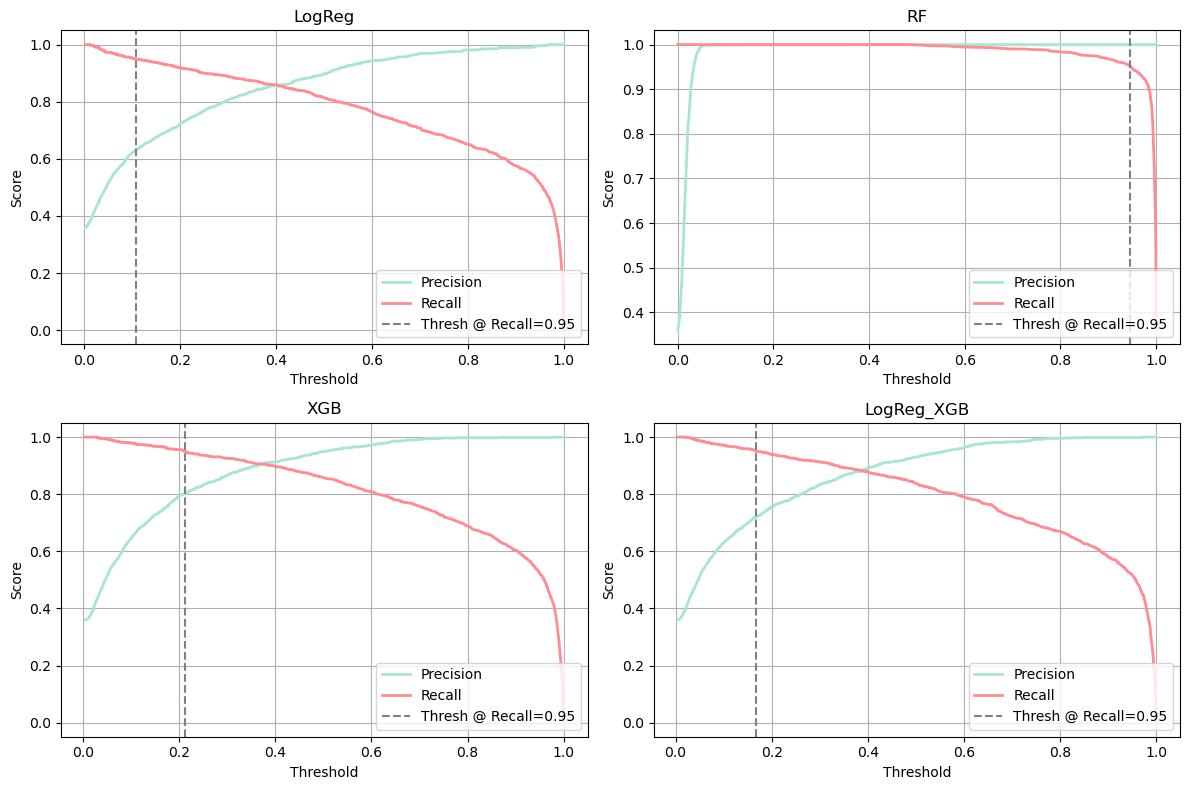

In [ ]:
model_results = {
    "LogReg": (y_train, logreg_m.predict_proba(X_train)[:,1]),
    "RF": (y_train, rf_m.predict_proba(X_train)[:,1]),
    "XGB": (y_train, xgb_m.predict_proba(X_train)[:,1]),
    "LogReg_XGB": (y_train, avg_comb_probs_tr["LogReg_XGB"])
}
thresholds = plot_precision_recall_vs_threshold_multi(model_results, target_recall=0.95, ncols=2)

RF somehow has a threshold of 1.0 to try keep recall at 0.95. Unclear why that is for this dataset. Other results still hold though.

## Model Results

In [29]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score)

In [30]:
# Predict class probabilities
y_proba = pd.DataFrame(logreg_m.predict_proba(X_test)[:,1], columns=["LogReg"])
y_proba["RF"] = rf_m.predict_proba(X_test)[:,1]
y_proba["XGB"] = xgb_m.predict_proba(X_test)[:,1]
y_proba.head()

,LogReg,RF,XGB
0,0.974902,0.932609,0.964547
1,0.025634,0.064327,0.015165
2,0.124022,0.054475,0.132515
3,0.194246,0.115459,0.094081
4,0.997329,0.992391,0.997452


In [44]:
avg_comb_probs_test = pd.DataFrame(ensemble.average_combinations(X_test, 2))
avg_comb_probs_test["True Label"] = y_test.values[:len(avg_comb_probs_test)]
avg_comb_probs_test.head()

,LogReg_RF,LogReg_XGB,RF_XGB,LogReg_RF_XGB,True Label
0,0.953755,0.969725,0.948578,0.957353,1
1,0.044980,0.020399,0.039746,0.035042,0
2,0.089248,0.128268,0.093495,0.103670,0
3,0.154853,0.144164,0.104770,0.134596,0
4,0.994860,0.997390,0.994922,0.995724,1


In [ ]:
# Compare ensemble models to determine representative

# Define model names and threshold
model_cols = avg_comb_probs_test.columns[:-1]

# Initialize list to collect metric results
metrics_list = []

# Compute metrics for each model
for model, best_threshold in thresholds_ensemble.items():
    y_probs = avg_comb_probs_test[model]
    y_pred = (y_probs >= best_threshold).astype(int)
    
    metrics = {
        'Model': model,
        'F1 Score': f1_score(y_test, y_pred),
        'Log Loss': log_loss(y_test, y_probs),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
    }
    metrics_list.append(metrics)

# Create DataFrame
metrics_df = pd.DataFrame(metrics_list)

# Format numbers to 3 decimals
metrics_df = metrics_df.round(3)

# Display table
print(metrics_df)

           Model  F1 Score  Log Loss  Accuracy  Precision  Recall
0      LogReg_RF     0.852     0.287     0.890      0.930   0.786
1     LogReg_XGB     0.825     0.288     0.844      0.749   0.918
2         RF_XGB     0.837     0.294     0.881      0.931   0.761
3  LogReg_RF_XGB     0.845     0.287     0.881      0.886   0.808


In [33]:
# Add best ensemble performer to y_proba
y_proba["LogReg_XGB"] = avg_comb_probs_test["LogReg_XGB"]
y_proba["True Label"] = y_test.values[:len(y_proba)]
y_proba.head()

,LogReg,RF,XGB,LogReg_XGB,True Label
0,0.974902,0.932609,0.964547,0.969725,1
1,0.025634,0.064327,0.015165,0.020399,0
2,0.124022,0.054475,0.132515,0.128268,0
3,0.194246,0.115459,0.094081,0.144164,0
4,0.997329,0.992391,0.997452,0.997390,1


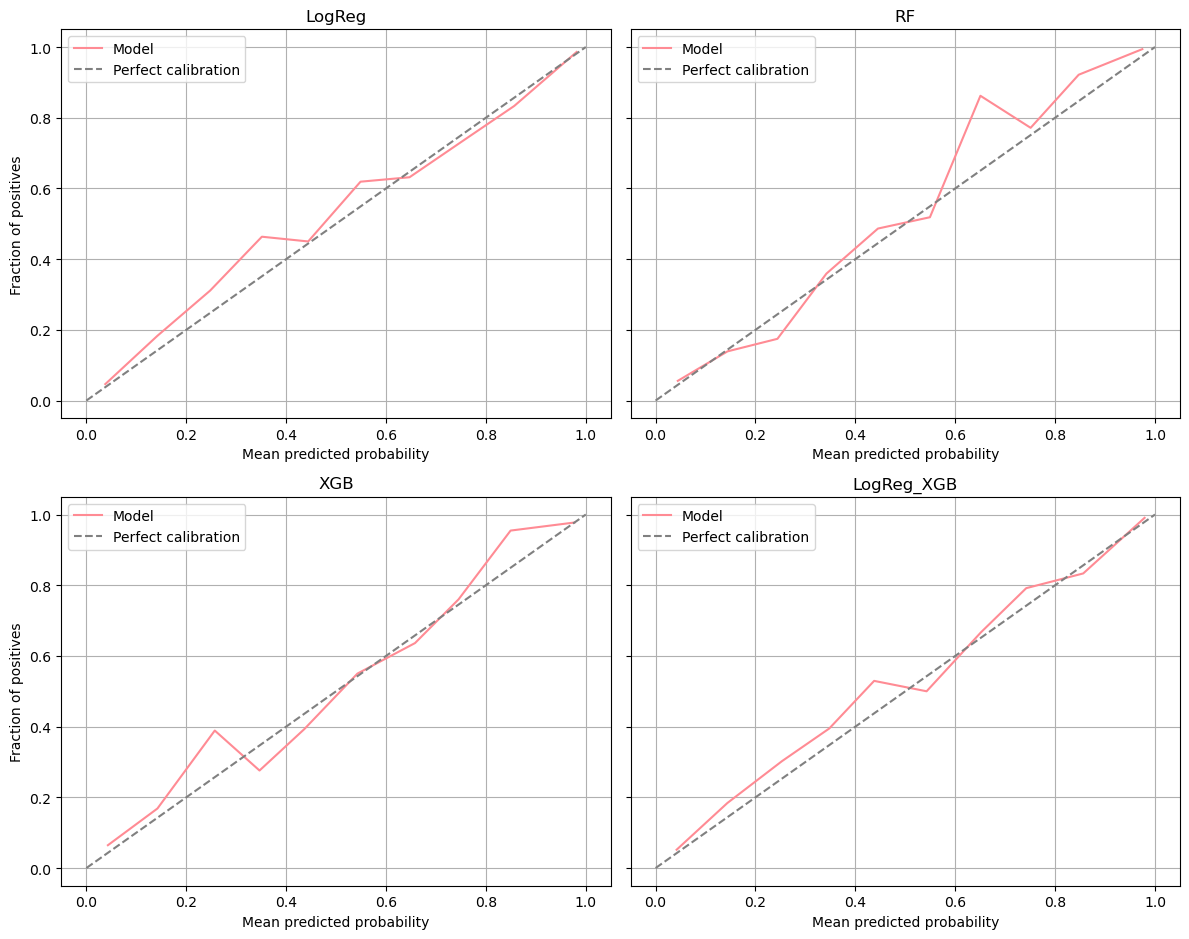

LogReg – Brier: 0.0867, Log Loss: 0.2931
RF – Brier: 0.0913, Log Loss: 0.3034
XGB – Brier: 0.0889, Log Loss: 0.2953
LogReg_XGB – Brier: 0.0861, Log Loss: 0.2876


In [ ]:
models = [
    'LogReg',
    'RF',
    'XGB',
    'LogReg_XGB'
]

# Setup plot in 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

# Flatten axes for easy iteration
axes = axes.flatten()

for i, name in enumerate(models):
    prob_true, prob_pred = calibration_curve(y_proba["True Label"], y_proba[name], n_bins=10)
    
    axes[i].plot(prob_pred, prob_true, '-', color=colors["Dropout"], label='Model')
    axes[i].plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
    
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Mean predicted probability')
    if i % 2 == 0:
        axes[i].set_ylabel('Fraction of positives')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Print Brier score and log loss on test set
for name in models:
    brier = brier_score_loss(y_test, y_proba[name])
    lloss = log_loss(y_test, y_proba[name])
    print(f'{name} – Brier: {brier:.4f}, Log Loss: {lloss:.4f}')

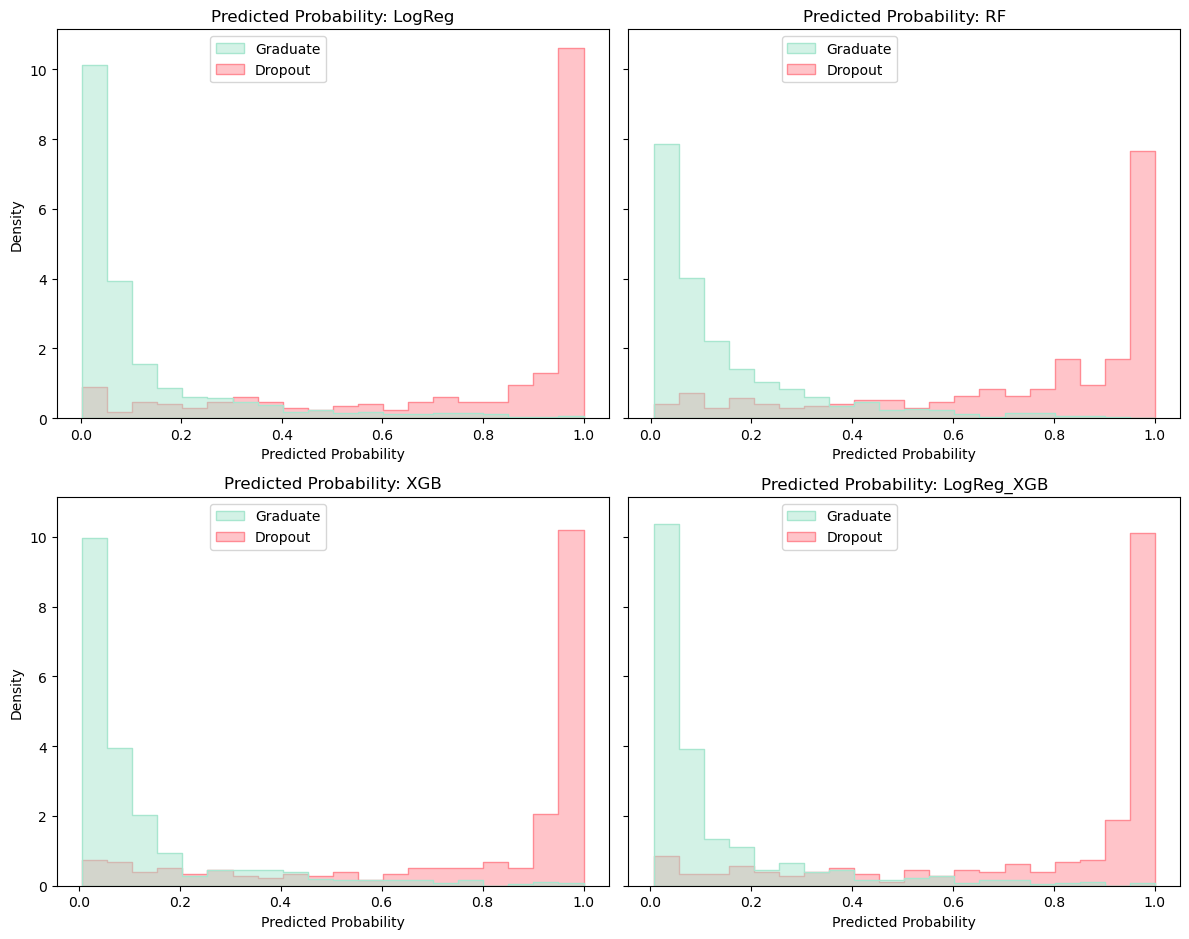

In [ ]:
# List of model probability column names
model_cols = ['LogReg', 'RF', 'XGB', 'LogReg_XGB']
custom_legend_labels = ["Graduate", "Dropout"]

# Setup 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

# Flatten axes array for easy iteration
axes = axes.flatten()

for i, model in enumerate(model_cols):
    sns.histplot(
        data=y_proba,
        x=model,
        hue='True Label',
        element='step',
        stat='density',
        common_norm=False,
        bins=20,
        ax=axes[i],
        palette={
            0: colors["Graduate"],
            1: colors["Dropout"]
        },
        alpha=0.5
    )
    axes[i].set_title(f'Predicted Probability: {model}')
    axes[i].set_xlabel('Predicted Probability')
    axes[i].set_ylabel('Density' if i % 2 == 0 else '')

    legend = axes[i].get_legend()
    if legend is not None:
        legend.set_title("")
        for text, new_label in zip(legend.get_texts(), custom_legend_labels):
            text.set_text(new_label)
        legend.set_bbox_to_anchor((0.5, 1))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

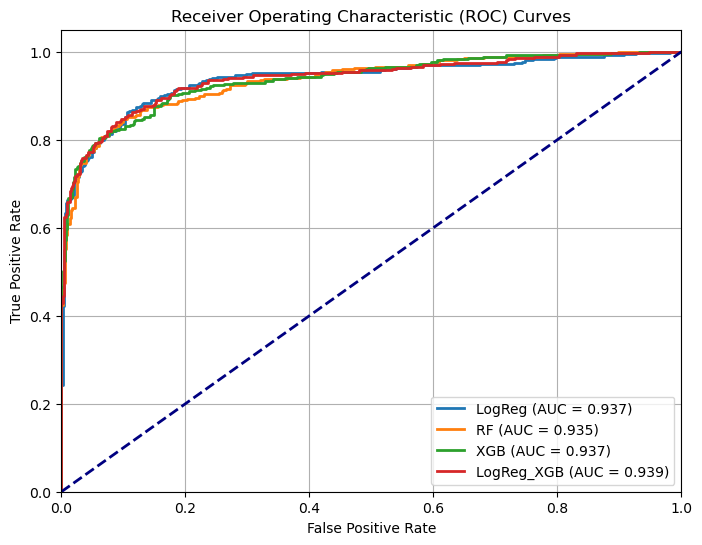

In [36]:
plt.figure(figsize=(8, 6))
for model_name, y_probs in y_proba.drop("True Label", axis=1).items():
    fpr, tpr, _ = roc_curve(y_proba["True Label"], y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

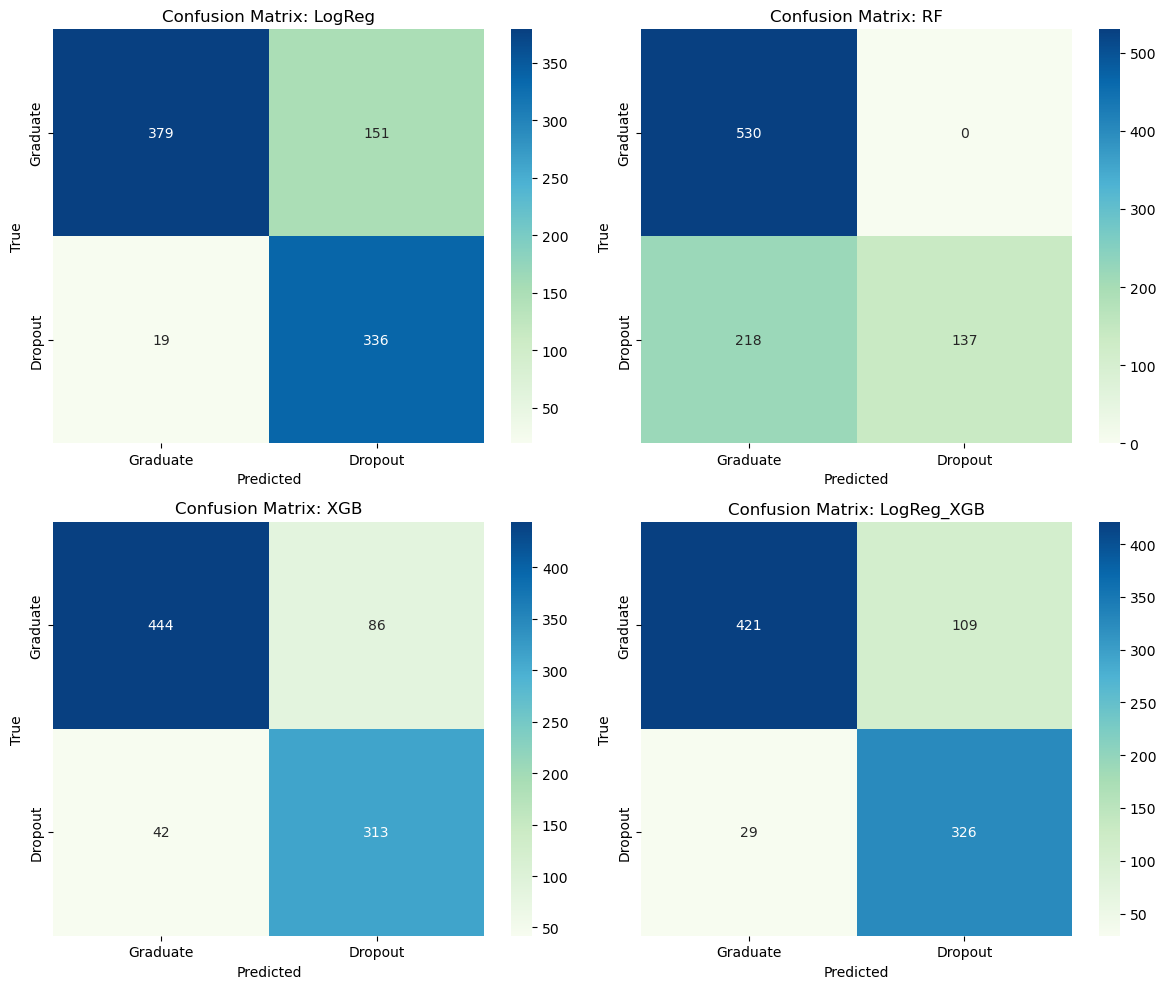

In [37]:
# Define model names and thresholds for converting probabilities to predicted classes
model_cols = ['LogReg', 'RF', 'XGB', 'LogReg_XGB']

# Set up 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Flatten the 2D axes array for easy iteration
axes = axes.flatten()

for i, (model, threshold) in enumerate(thresholds.items()):
    # Convert predicted probabilities to class labels
    y_pred = (y_proba[model] >= threshold).astype(int)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='GnBu',
        xticklabels=["Graduate", "Dropout"],
        yticklabels=["Graduate", "Dropout"],
        ax=axes[i]
    )

    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
    axes[i].set_title(f'Confusion Matrix: {model}')

plt.tight_layout()
plt.show()

In [ ]:
# Define model names and threshold
model_cols = y_proba.columns[:-1]

# Initialize list to collect metric results
metrics_list = []

thresholds = thresholds.copy()
thresholds["LogReg_XGB"] = thresholds_ensemble["LogReg_XGB"]

# Compute metrics for each model
for model, best_threshold in thresholds.items():
    y_probs = y_proba[model]
    y_pred = (y_probs >= best_threshold).astype(int)
    
    metrics = {
        'Model': model,
        'F1 Score': f1_score(y_test, y_pred),
        'Log Loss': log_loss(y_test, y_probs),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
    }
    metrics_list.append(metrics)

# Create DataFrame
metrics_df = pd.DataFrame(metrics_list)

# Format numbers to 3 decimals
metrics_df = metrics_df.round(3)

# Display table
print(metrics_df)

        Model  F1 Score  Log Loss  Accuracy  Precision  Recall
0      LogReg     0.798     0.293     0.808      0.690   0.946
1          RF     0.557     0.303     0.754      1.000   0.386
2         XGB     0.830     0.295     0.855      0.784   0.882
3  LogReg_XGB     0.825     0.288     0.844      0.749   0.918
